In [25]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
FRED_FILE = "fred_cpi_germany.json"
GDELT_FILE = "gdelt_API.json"

START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

HIGH_INFLATION_QUANTILE = 0.75
MIN_ARTICLES_PER_MONTH = 1

In [27]:
def load_fred_json(filepath):
    """
    Load a local JSON file that stores a mapping from date to CPI value.
    """
    with open(filepath, "r", encoding="utf-8") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(list(raw_data.items()), columns=["date", "cpi"])
    return dataframe


def load_gdelt_json(filepath):
    """
    Load a local JSON file that stores a list of article dictionaries.
    """
    with open(filepath, "r", encoding="utf-8") as file:
        raw_data = json.load(file)

    dataframe = pd.DataFrame(raw_data)
    return dataframe

In [28]:
def clean_cpi_data(dataframe):
    """
    Clean CPI data and keep only the selected period.
    """
    cleaned = dataframe.copy()

    cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce")
    cleaned["cpi"] = pd.to_numeric(cleaned["cpi"], errors="coerce")

    cleaned = cleaned.dropna(subset=["date", "cpi"])
    cleaned = cleaned.drop_duplicates(subset=["date"])
    cleaned = cleaned.sort_values("date").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["date"] >= START_DATE) &
        (cleaned["date"] <= END_DATE)
    ].copy()

    return cleaned


def clean_gdelt_data(dataframe):
    """
    Clean GDELT article data and keep useful columns.
    """
    cleaned = dataframe.copy()

    useful_columns = ["title", "seendate", "language", "sourcecountry", "domain"]
    available_columns = [column for column in useful_columns if column in cleaned.columns]
    cleaned = cleaned[available_columns].copy()

    cleaned["title"] = cleaned["title"].astype(str).str.strip()
    cleaned["seendate"] = pd.to_datetime(
        cleaned["seendate"],
        errors="coerce",
        format="%Y%m%dT%H%M%SZ"
    )

    cleaned = cleaned.dropna(subset=["title", "seendate"])
    cleaned = cleaned[cleaned["title"] != ""]
    cleaned = cleaned.drop_duplicates(subset=["title", "seendate"])
    cleaned = cleaned.sort_values("seendate").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["seendate"] >= START_DATE) &
        (cleaned["seendate"] <= END_DATE)
    ].copy()

    return cleaned

In [31]:
def add_cpi_features(dataframe):
    """
    Add month, year, and inflation measures.
    """
    result = dataframe.copy()

    result["year"] = result["date"].dt.year
    result["month_number"] = result["date"].dt.month
    result["month"] = result["date"].dt.to_period("M").dt.to_timestamp()

    result["inflation_mom"] = result["cpi"].pct_change(periods=1) * 100
    result["inflation_yoy"] = result["cpi"].pct_change(periods=12) * 100

    return result


def add_gdelt_time_features(dataframe):
    """
    Add year and month information to GDELT data.
    """
    result = dataframe.copy()

    result["year"] = result["seendate"].dt.year
    result["month_number"] = result["seendate"].dt.month
    result["month"] = result["seendate"].dt.to_period("M").dt.to_timestamp()

    return result


def aggregate_articles_monthly(dataframe):
    """
    Aggregate article data to monthly counts.
    """
    monthly = (
        dataframe.groupby("month", as_index=False)
        .agg(
            article_count=("title", "count")
        )
        .sort_values("month")
        .reset_index(drop=True)
    )

    return monthly


def assign_inflation_regime(dataframe, quantile=0.75):
    """
    Split months into high-inflation and lower-inflation periods.
    """
    result = dataframe.copy()

    threshold = result["inflation_yoy"].quantile(quantile)

    result["inflation_regime"] = "lower_inflation"
    result.loc[result["inflation_yoy"] >= threshold, "inflation_regime"] = "high_inflation"

    return result, threshold

In [32]:
cpi_raw = load_fred_json(FRED_FILE)
gdelt_raw = load_gdelt_json(GDELT_FILE)

print("CPI raw shape:", cpi_raw.shape)
print("GDELT raw shape:", gdelt_raw.shape)

CPI raw shape: (843, 2)
GDELT raw shape: (100, 8)


In [33]:
cpi_clean = clean_cpi_data(cpi_raw)
gdelt_clean = clean_gdelt_data(gdelt_raw)

print("CPI cleaned shape:", cpi_clean.shape)
print("GDELT cleaned shape:", gdelt_clean.shape)

CPI cleaned shape: (60, 2)
GDELT cleaned shape: (100, 5)


In [34]:
cpi_features = add_cpi_features(cpi_clean)
gdelt_features = add_gdelt_time_features(gdelt_clean)

gdelt_monthly = aggregate_articles_monthly(gdelt_features)

print("Monthly article data shape:", gdelt_monthly.shape)

gdelt_monthly.head()

Monthly article data shape: (4, 2)


,month,article_count
0,2023-10-01,30
1,2023-11-01,33
2,2023-12-01,34
3,2024-01-01,3


In [35]:
analysis_df = pd.merge(
    cpi_features[["month", "date", "cpi", "inflation_mom", "inflation_yoy"]],
    gdelt_monthly,
    on="month",
    how="inner"
)

analysis_df = analysis_df.dropna(subset=["inflation_yoy"])
analysis_df = analysis_df[analysis_df["article_count"] >= MIN_ARTICLES_PER_MONTH].copy()
analysis_df = analysis_df.sort_values("month").reset_index(drop=True)

analysis_df, inflation_threshold = assign_inflation_regime(
    analysis_df,
    quantile=HIGH_INFLATION_QUANTILE
)

print("Inflation threshold (YoY):", round(inflation_threshold, 2))
print("Final analysis shape:", analysis_df.shape)

analysis_df.head()

Inflation threshold (YoY): 3.73
Final analysis shape: (4, 7)


,month,date,cpi,inflation_mom,inflation_yoy,article_count,inflation_regime
0,2023-10-01,2023-10-01,124.1946,0.000000,3.788530,30,high_inflation
1,2023-11-01,2023-11-01,123.6675,-0.424415,3.166208,33,lower_inflation
2,2023-12-01,2023-12-01,123.7729,0.085229,3.710255,34,lower_inflation
3,2024-01-01,2024-01-01,123.9838,0.170393,2.887107,3,lower_inflation


In [36]:
summary_table = (
    analysis_df.groupby("inflation_regime")
    .agg(
        average_article_count=("article_count", "mean"),
        average_inflation_yoy=("inflation_yoy", "mean"),
        number_of_months=("month", "count")
    )
    .round(2)
)

summary_table

,average_article_count,average_inflation_yoy,number_of_months
inflation_regime,,,
high_inflation,30.00,3.79,1
lower_inflation,23.33,3.25,3


In [37]:
correlation_value = analysis_df[["inflation_yoy", "article_count"]].corr().iloc[0, 1]
print("Correlation between inflation_yoy and article_count:", round(correlation_value, 3))

Correlation between inflation_yoy and article_count: 0.736


In [38]:
sns.set_theme(style="whitegrid")

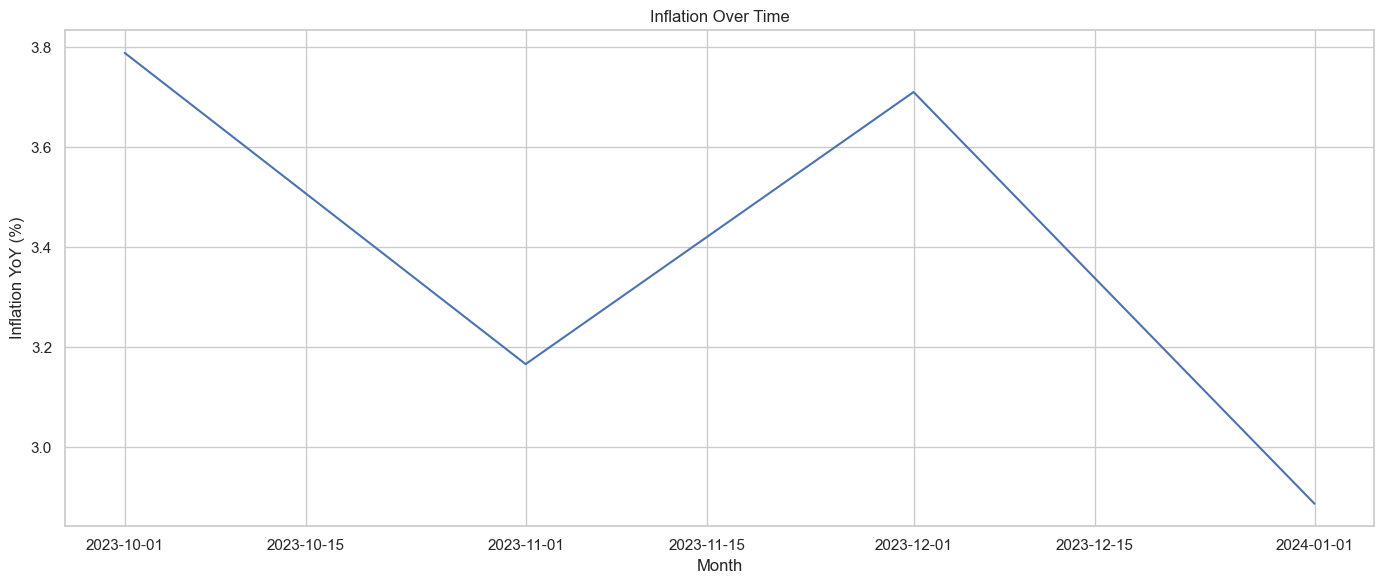

In [39]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=analysis_df, x="month", y="inflation_yoy")

plt.title("Inflation Over Time")
plt.xlabel("Month")
plt.ylabel("Inflation YoY (%)")
plt.tight_layout()
plt.show()

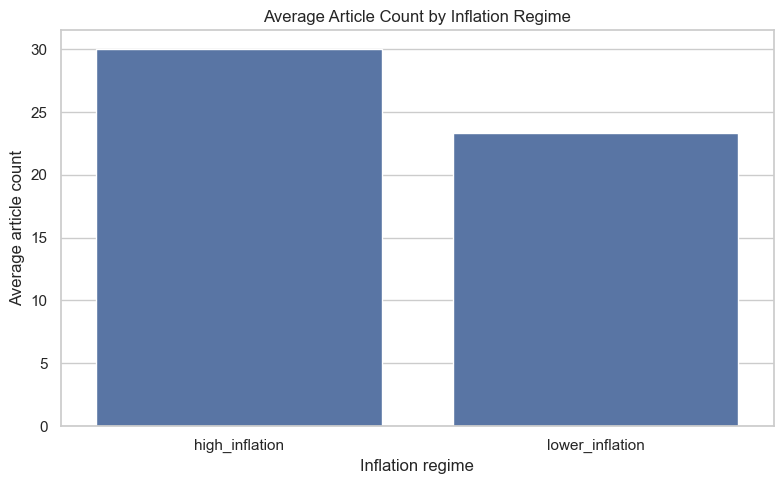

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(data=summary_table.reset_index(), x="inflation_regime", y="average_article_count")

plt.title("Average Article Count by Inflation Regime")
plt.xlabel("Inflation regime")
plt.ylabel("Average article count")
plt.tight_layout()
plt.show()

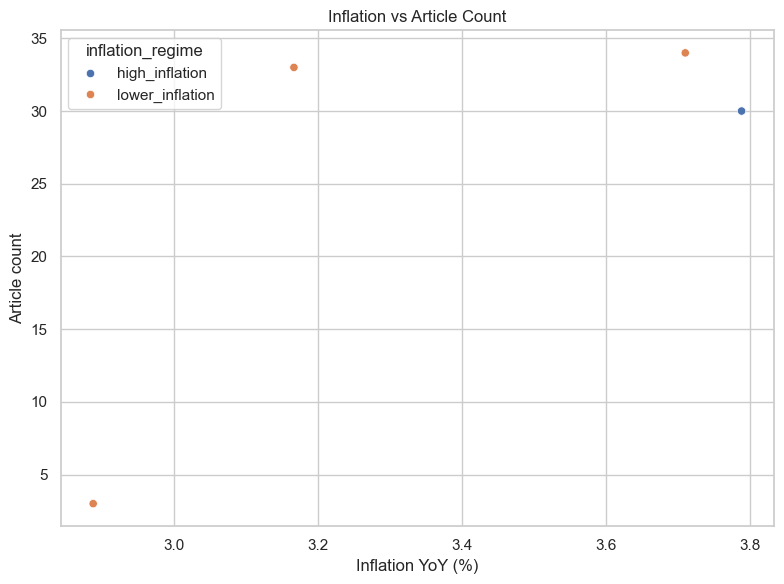

In [41]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=analysis_df, x="inflation_yoy", y="article_count", hue="inflation_regime")

plt.title("Inflation vs Article Count")
plt.xlabel("Inflation YoY (%)")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

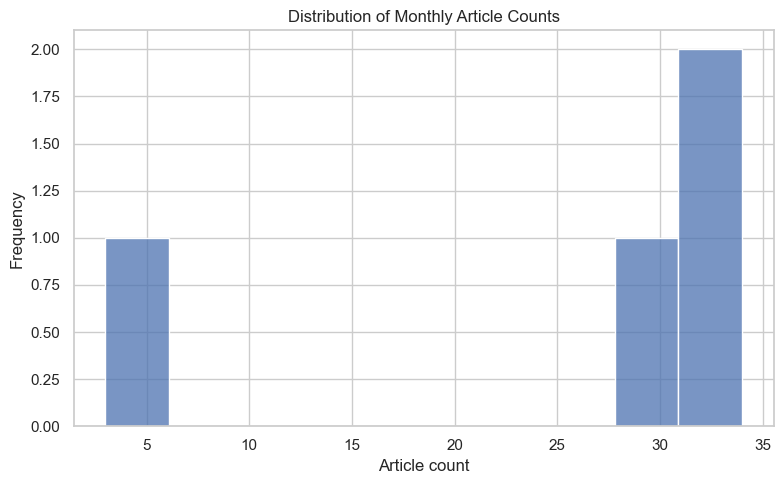

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(data=analysis_df, x="article_count", bins=10)

plt.title("Distribution of Monthly Article Counts")
plt.xlabel("Article count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

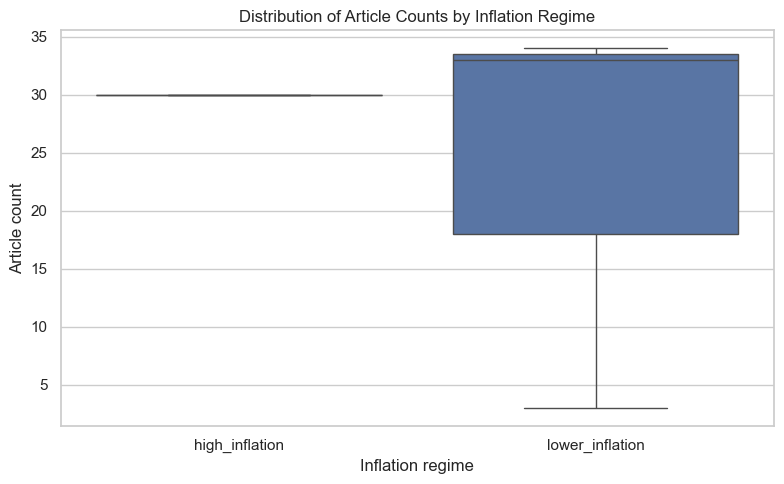

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=analysis_df, x="inflation_regime", y="article_count")

plt.title("Distribution of Article Counts by Inflation Regime")
plt.xlabel("Inflation regime")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

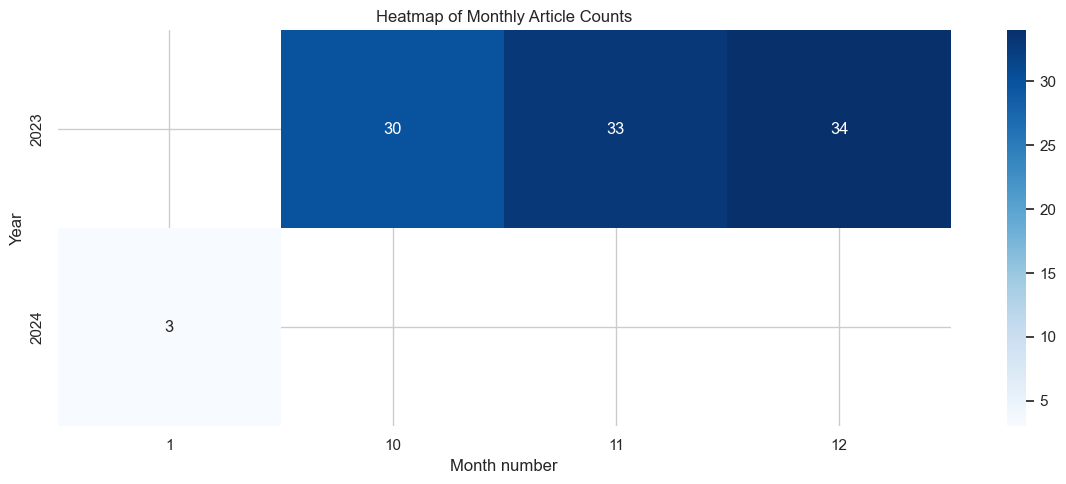

In [44]:
heatmap_df = analysis_df.copy()
heatmap_df["year"] = heatmap_df["month"].dt.year
heatmap_df["month_number"] = heatmap_df["month"].dt.month

pivot_df = heatmap_df.pivot_table(
    index="year",
    columns="month_number",
    values="article_count",
    aggfunc="mean"
)

plt.figure(figsize=(12, 5))

sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="Blues")

plt.title("Heatmap of Monthly Article Counts")
plt.xlabel("Month number")
plt.ylabel("Year")
plt.tight_layout()
plt.show()